# 05 — Model Training (Baseline + Enhanced)

Trains classifiers on Swiss SPI Extra stock data and compares old single-period approach with new multi-period, walk-forward, ensemble, and binary approaches.

**Part A — Setup & Data Loading** (shared)  
**Part B — BASELINE: Single-Period Training** (RF + XGB on Q1 2024 only)  
**Part C — ENHANCED: Multi-Period Training** (walk-forward CV, RFECV, rank features, sector dummies, LightGBM, ensemble, binary, calibration)  
**Part D — Model Comparison** (side-by-side metrics)

In [1]:
from __future__ import annotations

import sys
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import config
from src.classifier import assign_groups, compute_q1_returns, compute_multi_period_returns
from src.data_loader import download_ohlcv, load_fundamentals
from src.features import (
    build_feature_matrix,
    build_multi_period_feature_matrix,
    build_rank_features,
    build_sector_dummies,
    drop_correlated_features,
    audit_fundamental_coverage,
)
from src.model import (
    plot_confusion_matrix,
    plot_cv_folds,
    plot_model_comparison,
    predict,
    predict_proba,
    predict_with_threshold,
    refit_on_full_data,
    save_model,
    shap_explain,
    train_classifier,
    train_ensemble,
)
from src.universe import filter_by_min_volume, get_spi_extra_tickers

try:
    from IPython.display import display
except ImportError:
    display = print

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_rows", 40)
pd.set_option("display.width", 120)
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Project root: {PROJECT_ROOT}")
print(f"Feature cutoff: {config.FEATURE_CUTOFF_DATE}")
print(f"Random seed: {config.RANDOM_SEED}")
print(f"Train/test split: {config.TRAIN_TEST_SPLIT:.0%} / {1 - config.TRAIN_TEST_SPLIT:.0%}")
print(f"CV folds: {config.CV_FOLDS}")
print(f"Classification periods: {len(config.CLASSIFICATION_PERIODS)}")

Project root: /Users/stephangath/cursorAi/Stock Analysis AI
Feature cutoff: 2023-12-31
Random seed: 42
Train/test split: 75% / 25%
CV folds: 5
Classification periods: 7


## Part A — Data Loading

Universe, OHLCV (cache), liquidity filter, fundamentals.

In [2]:
tickers = get_spi_extra_tickers()
print(f"SPI Extra universe: {len(tickers)} tickers")

ohlcv = download_ohlcv(
    tickers,
    start=config.YF_START,
    end=config.YF_END,
    cache_dir=config.DATA_DIR,
)
print(f"OHLCV loaded: {len(ohlcv)} tickers")

liquid_tickers = filter_by_min_volume(ohlcv, config.MIN_DAILY_VOLUME_CHF)
liquid = {t: ohlcv[t] for t in liquid_tickers if t in ohlcv}
print(f"After liquidity filter: {len(liquid)} tickers")

fundamentals: dict[str, dict] = {}
with ThreadPoolExecutor(max_workers=8) as pool:
    futs = {
        pool.submit(load_fundamentals, t, cache_dir=config.DATA_DIR): t
        for t in liquid
    }
    for fut in as_completed(futs):
        t = futs[fut]
        try:
            fundamentals[t] = fut.result()
        except Exception:
            pass
print(f"Fundamentals loaded: {len(fundamentals)} tickers")

SPI Extra universe: 194 tickers


$ACHI.SW: possibly delisted; no timezone found

1 Failed download:
['ACHI.SW']: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AFP.SW"}}}
$AFP.SW: possibly delisted; no timezone found

1 Failed download:
['AFP.SW']: possibly delisted; no timezone found
$AIRE.SW: possibly delisted; no timezone found

1 Failed download:
['AIRE.SW']: possibly delisted; no timezone found
$ARON.SW: possibly delisted; no timezone found

1 Failed download:
['ARON.SW']: possibly delisted; no timezone found
$BALN.SW: possibly delisted; no timezone found

1 Failed download:
['BALN.SW']: possibly delisted; no timezone found
$BLS.SW: possibly delisted; no timezone found

1 Failed download:
['BLS.SW']: possibly delisted; no timezone found
$BOBNN.SW: possibly delisted; no timezone found

1 Failed download:
['BOBNN.SW']: possibly delisted; no timezone found
$BPDG.SW: possibly delisted; no timezone found

1 Fail

OHLCV loaded: 154 tickers
After liquidity filter: 136 tickers
Fundamentals loaded: 136 tickers


---
## Part B — BASELINE: Single-Period Training

Train on Q1 2024 labels only (original approach). Feature cutoff: 2023-12-31.

In [3]:
X_baseline = build_feature_matrix(
    liquid,
    cutoff_date=config.FEATURE_CUTOFF_DATE,
    fundamentals_by_ticker=fundamentals,
)

returns_baseline = compute_q1_returns(liquid)
y_baseline = assign_groups(returns_baseline, method="percentile")

common = X_baseline.index.intersection(y_baseline.dropna().index)
X_baseline = X_baseline.loc[common]
y_baseline = y_baseline.loc[common]

min_nonna = max(3, int(0.05 * len(X_baseline)))
good_cols = X_baseline.columns[X_baseline.notna().sum() >= min_nonna]
X_baseline = X_baseline[good_cols]

print(f"\n[BASELINE] Feature matrix: {X_baseline.shape[0]} stocks × {X_baseline.shape[1]} features")
print("Label distribution:")
display(y_baseline.value_counts().reindex(["Winners", "Steady", "Losers"]))


[BASELINE] Feature matrix: 135 stocks × 28 features
Label distribution:


Winners    34
Steady     67
Losers     34
Name: count, dtype: int64

### BASELINE — Random Forest (GridSearchCV)

In [4]:
%%time

rf_baseline = train_classifier(
    X_baseline, y_baseline,
    random_state=config.RANDOM_SEED,
    model_type="rf",
    tune=True,
)

print(f"\nTrain / Test: {len(rf_baseline.X_train)} / {len(rf_baseline.X_test)}")
print(f"Classes: {rf_baseline.class_names}")
print(f"\nBest hyperparameters:")
for k, v in rf_baseline.best_params.items():
    print(f"  {k}: {v}")


Train / Test: 101 / 34
Classes: ['Losers', 'Steady', 'Winners']

Best hyperparameters:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 3
  min_samples_split: 2
  n_estimators: 500
CPU times: user 2.22 s, sys: 406 ms, total: 2.62 s
Wall time: 30.7 s


=== BASELINE Random Forest: CV vs Hold-out ===


,CV (mean ± std),Hold-out
Accuracy,0.566 ± 0.098,0.441
F1 macro,0.517 ± 0.123,0.392
F1 weighted,0.558 ± 0.113,0.431



=== Hold-out Classification Report ===
              precision    recall  f1-score   support

      Losers       0.33      0.22      0.27         9
      Steady       0.53      0.59      0.56        17
     Winners       0.33      0.38      0.35         8

    accuracy                           0.44        34
   macro avg       0.40      0.40      0.39        34
weighted avg       0.43      0.44      0.43        34



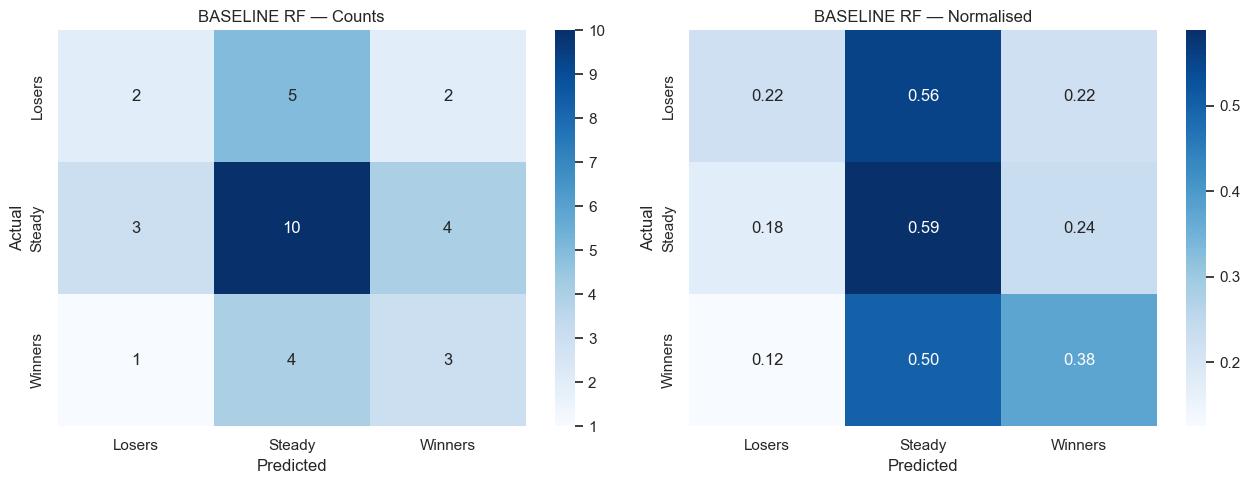

In [5]:
cv = rf_baseline.cv_results
holdout = rf_baseline.holdout_metrics

comparison_df = pd.DataFrame({
    "CV (mean ± std)": {
        "Accuracy": f"{cv['accuracy_mean']:.3f} ± {cv['accuracy_std']:.3f}",
        "F1 macro": f"{cv['f1_macro_mean']:.3f} ± {cv['f1_macro_std']:.3f}",
        "F1 weighted": f"{cv['f1_weighted_mean']:.3f} ± {cv['f1_weighted_std']:.3f}",
    },
    "Hold-out": {
        "Accuracy": f"{holdout['accuracy']:.3f}",
        "F1 macro": f"{holdout['f1_macro']:.3f}",
        "F1 weighted": f"{holdout['f1_weighted']:.3f}",
    },
})
print("=== BASELINE Random Forest: CV vs Hold-out ===")
display(comparison_df)

print("\n=== Hold-out Classification Report ===")
print(holdout["report_str"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_confusion_matrix(holdout, rf_baseline.class_names, title="BASELINE RF — Counts", ax=axes[0])
plot_confusion_matrix(holdout, rf_baseline.class_names, title="BASELINE RF — Normalised", normalize=True, ax=axes[1])
plt.tight_layout()
plt.show()

### BASELINE — XGBoost (GridSearchCV)

In [6]:
%%time

xgb_baseline = train_classifier(
    X_baseline, y_baseline,
    random_state=config.RANDOM_SEED,
    model_type="xgb",
    tune=True,
)

print(f"\nBest XGB params:")
for k, v in xgb_baseline.best_params.items():
    print(f"  {k}: {v}")

print(f"\n=== BASELINE XGBoost: Hold-out ===")
print(xgb_baseline.holdout_metrics["report_str"])


Best XGB params:
  colsample_bytree: 0.8
  learning_rate: 0.01
  max_depth: 7
  n_estimators: 300
  subsample: 1.0

=== BASELINE XGBoost: Hold-out ===
              precision    recall  f1-score   support

      Losers       0.00      0.00      0.00         9
      Steady       0.57      0.71      0.63        17
     Winners       0.30      0.38      0.33         8

    accuracy                           0.44        34
   macro avg       0.29      0.36      0.32        34
weighted avg       0.36      0.44      0.39        34

CPU times: user 4.22 s, sys: 7.24 s, total: 11.5 s
Wall time: 17.2 s


### BASELINE — Refit & Save

Refit the best baseline model (RF) on all Q1-2024 labelled data for forward testing.

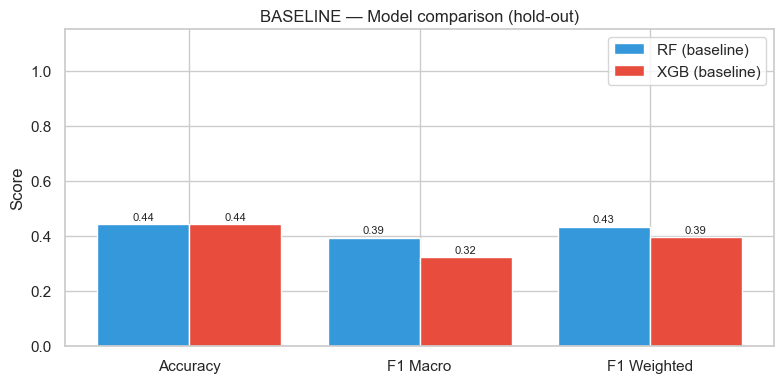


Baseline model saved to /Users/stephangath/cursorAi/Stock Analysis AI/data/models/baseline_classifier.joblib


In [7]:
baseline_models = {"RF (baseline)": rf_baseline, "XGB (baseline)": xgb_baseline}
plot_model_comparison(baseline_models, title="BASELINE — Model comparison (hold-out)")
plt.show()

best_baseline = rf_baseline
baseline_final = refit_on_full_data(X_baseline, y_baseline, best_baseline, random_state=config.RANDOM_SEED)

model_dir = config.DATA_DIR / "models"
save_model(baseline_final, model_dir / "baseline_classifier.joblib")
print(f"\nBaseline model saved to {model_dir / 'baseline_classifier.joblib'}")

---
## Part C — ENHANCED: Multi-Period Training

Stack multiple quarters (Q2-2023 … Q4-2024) for ~7× more training samples.  
Enhanced features: rank features, sector dummies, correlated feature removal, RFECV.  
Models: RF, XGB, LightGBM, Ensemble (RF+XGB), Binary (Winner vs Rest).  
Walk-forward CV respects temporal ordering.

In [8]:
multi_returns, multi_labels = compute_multi_period_returns(
    liquid,
    config.CLASSIFICATION_PERIODS,
    method="percentile",
)
print(f"\nMulti-period returns: {multi_returns.shape}")
print(f"Period distribution:\n{multi_returns['period'].value_counts().sort_index()}")
print(f"\nLabel distribution:\n{multi_labels.value_counts()}")


Multi-period returns: (945, 6)
Period distribution:
period
Q1-2024    135
Q2-2023    135
Q2-2024    135
Q3-2023    135
Q3-2024    135
Q4-2023    135
Q4-2024    135
Name: count, dtype: int64

Label distribution:
label
Steady     469
Losers     238
Winners    238
Name: count, dtype: int64


In [9]:
X_multi = build_multi_period_feature_matrix(
    liquid,
    multi_returns,
    fundamentals_by_ticker=fundamentals,
)
print(f"\nMulti-period feature matrix: {X_multi.shape}")


Multi-period feature matrix: (945, 28)


In [10]:
rank_feats = build_rank_features(X_multi)
print(f"Rank features: {rank_feats.shape}")

sector_dummies = build_sector_dummies(fundamentals)
print(f"Sector dummies: {sector_dummies.shape}")

ticker_col = multi_returns["ticker"]
sector_aligned = pd.DataFrame(index=X_multi.index)
for obs_id in X_multi.index:
    ticker = multi_returns.loc[obs_id, "ticker"]
    if ticker in sector_dummies.index:
        for col in sector_dummies.columns:
            sector_aligned.loc[obs_id, col] = sector_dummies.loc[ticker, col]
    else:
        for col in sector_dummies.columns:
            sector_aligned.loc[obs_id, col] = 0.0

X_enhanced = pd.concat([X_multi, rank_feats, sector_aligned], axis=1)

X_enhanced, dropped = drop_correlated_features(X_enhanced, threshold=0.85)
print(f"\nAfter correlation filter: {X_enhanced.shape[1]} features (dropped {len(dropped)})")
if dropped:
    print(f"  Dropped: {dropped}")

Rank features: (945, 28)
Sector dummies: (136, 10)

After correlation filter: 54 features (dropped 12)
  Dropped: ['atr_14_pct', 'zscore_20d', 'rank_rsi_14', 'rank_sma_ratio_50_200', 'rank_adx_14', 'rank_hvol_60d', 'rank_atr_14_pct', 'rank_volume_ratio_20_60', 'rank_rel_volume_5d', 'rank_dist_52w_high', 'rank_zscore_20d', 'rank_market_cap_log']


In [11]:
common_enhanced = X_enhanced.index.intersection(multi_labels.dropna().index)
X_enhanced = X_enhanced.loc[common_enhanced]
y_enhanced = multi_labels.loc[common_enhanced]

period_labels = multi_returns.loc[common_enhanced, "period"]

print(f"\nEnhanced training set: {X_enhanced.shape[0]} obs × {X_enhanced.shape[1]} features")
print(f"Periods: {period_labels.unique().tolist()}")


Enhanced training set: 945 obs × 54 features
Periods: ['Q2-2023', 'Q3-2023', 'Q4-2023', 'Q1-2024', 'Q2-2024', 'Q3-2024', 'Q4-2024']


### ENHANCED — Random Forest (Walk-Forward CV + RFECV)

In [12]:
%%time

rf_enhanced = train_classifier(
    X_enhanced, y_enhanced,
    random_state=config.RANDOM_SEED,
    model_type="rf",
    tune=True,
    period_labels=period_labels.values,
    walk_forward=True,
    min_train_periods=2,
    feature_selection=True,
    rfecv_min_features=5,
    calibrate=True,
    calibration_method="sigmoid",
)

print(f"\nTrain / Test: {len(rf_enhanced.X_train)} / {len(rf_enhanced.X_test)}")
print(f"Features after RFECV: {len(rf_enhanced.feature_names)}")
if rf_enhanced.selected_features:
    print(f"  Selected: {rf_enhanced.selected_features}")
print(f"Calibrated: {rf_enhanced.calibrated}")
print(f"\nBest params: {rf_enhanced.best_params}")
print(f"\n=== ENHANCED RF: Hold-out ===")
print(rf_enhanced.holdout_metrics["report_str"])


Train / Test: 810 / 135
Features after RFECV: 17
  Selected: ['rsi_14', 'sma_ratio_50_200', 'adx_14', 'hvol_20d', 'hvol_60d', 'bb_width', 'volume_ratio_20_60', 'rel_volume_5d', 'dist_52w_high', 'dist_52w_low', 'profit_margin', 'market_cap_log', 'rank_mom_6m', 'rank_hvol_20d', 'rank_dist_52w_low', 'rank_pb_ratio', 'rank_profit_margin']
Calibrated: True

Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100}

=== ENHANCED RF: Hold-out ===
              precision    recall  f1-score   support

      Losers       0.38      0.35      0.36        34
      Steady       0.48      0.61      0.54        67
     Winners       0.24      0.12      0.16        34

    accuracy                           0.42       135
   macro avg       0.36      0.36      0.35       135
weighted avg       0.39      0.42      0.40       135

CPU times: user 10.3 s, sys: 1.99 s, total: 12.3 s
Wall time: 52 s


### ENHANCED — XGBoost (Walk-Forward CV)

In [13]:
%%time

xgb_enhanced = train_classifier(
    X_enhanced, y_enhanced,
    random_state=config.RANDOM_SEED,
    model_type="xgb",
    tune=True,
    period_labels=period_labels.values,
    walk_forward=True,
    min_train_periods=2,
    calibrate=True,
)

print(f"\n=== ENHANCED XGB: Hold-out ===")
print(xgb_enhanced.holdout_metrics["report_str"])


=== ENHANCED XGB: Hold-out ===
              precision    recall  f1-score   support

      Losers       0.41      0.26      0.32        34
      Steady       0.49      0.69      0.57        67
     Winners       0.16      0.09      0.11        34

    accuracy                           0.43       135
   macro avg       0.35      0.35      0.34       135
weighted avg       0.39      0.43      0.39       135

CPU times: user 1.72 s, sys: 1.06 s, total: 2.78 s
Wall time: 1min 29s


### ENHANCED — LightGBM (Walk-Forward CV)

In [14]:
%%time

lgb_enhanced = train_classifier(
    X_enhanced, y_enhanced,
    random_state=config.RANDOM_SEED,
    model_type="lgb",
    tune=True,
    period_labels=period_labels.values,
    walk_forward=True,
    min_train_periods=2,
    calibrate=True,
)

print(f"\n=== ENHANCED LGB: Hold-out ===")
print(lgb_enhanced.holdout_metrics["report_str"])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/


=== ENHANCED LGB: Hold-out ===
              precision    recall  f1-score   support

      Losers       0.48      0.32      0.39        34
      Steady       0.51      0.70      0.59        67
     Winners       0.16      0.09      0.11        34

    accuracy                           0.45       135
   macro avg       0.38      0.37      0.36       135
weighted avg       0.41      0.45      0.42       135

CPU times: user 855 ms, sys: 879 ms, total: 1.73 s
Wall time: 41 s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/

### ENHANCED — Ensemble (RF + XGB, averaged probabilities)

In [15]:
%%time

ensemble_enhanced = train_ensemble(
    X_enhanced, y_enhanced,
    random_state=config.RANDOM_SEED,
    tune=True,
    period_labels=period_labels.values,
    walk_forward=True,
    min_train_periods=2,
    calibrate=True,
)

print(f"\n=== ENHANCED Ensemble: Hold-out ===")
print(ensemble_enhanced.holdout_metrics["report_str"])


=== ENHANCED Ensemble: Hold-out ===
              precision    recall  f1-score   support

      Losers       0.44      0.32      0.37        34
      Steady       0.50      0.70      0.58        67
     Winners       0.19      0.09      0.12        34

    accuracy                           0.45       135
   macro avg       0.38      0.37      0.36       135
weighted avg       0.41      0.45      0.41       135

CPU times: user 12.6 s, sys: 6.3 s, total: 18.9 s
Wall time: 2min 29s


### ENHANCED — Binary Classification (Winner vs Rest)

In [16]:
%%time

binary_enhanced = train_classifier(
    X_enhanced, y_enhanced,
    random_state=config.RANDOM_SEED,
    model_type="rf",
    problem_type="binary",
    tune=True,
    period_labels=period_labels.values,
    walk_forward=True,
    min_train_periods=2,
    calibrate=True,
)

print(f"\n=== ENHANCED Binary (Winner vs Rest): Hold-out ===")
print(binary_enhanced.holdout_metrics["report_str"])


=== ENHANCED Binary (Winner vs Rest): Hold-out ===
              precision    recall  f1-score   support

        Rest       0.76      0.98      0.86       101
     Winners       0.60      0.09      0.15        34

    accuracy                           0.76       135
   macro avg       0.68      0.53      0.51       135
weighted avg       0.72      0.76      0.68       135

CPU times: user 936 ms, sys: 434 ms, total: 1.37 s
Wall time: 37.5 s


---
## Part D — Model Comparison

=== All Models — Hold-out Comparison ===


,Accuracy,F1 macro,F1 weighted,Calibrated,n_features,n_train,n_test
Model,,,,,,,
RF (baseline),0.441,0.392,0.431,False,28,101,34
XGB (baseline),0.441,0.322,0.394,False,28,101,34
RF (enhanced),0.422,0.352,0.397,True,17,810,135
XGB (enhanced),0.430,0.335,0.393,True,54,810,135
LGB (enhanced),0.452,0.362,0.417,True,54,810,135
Ensemble (enhanced),0.452,0.359,0.414,True,54,810,135


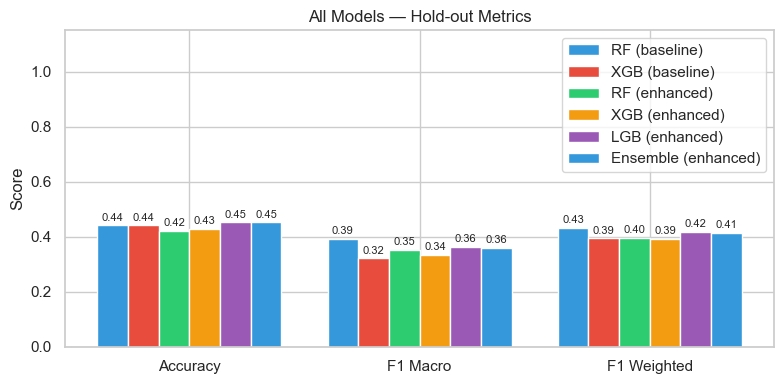

In [17]:
all_models = {
    "RF (baseline)": rf_baseline,
    "XGB (baseline)": xgb_baseline,
    "RF (enhanced)": rf_enhanced,
    "XGB (enhanced)": xgb_enhanced,
    "LGB (enhanced)": lgb_enhanced,
    "Ensemble (enhanced)": ensemble_enhanced,
}

rows = []
for name, result in all_models.items():
    h = result.holdout_metrics
    rows.append({
        "Model": name,
        "Accuracy": f"{h['accuracy']:.3f}",
        "F1 macro": f"{h['f1_macro']:.3f}",
        "F1 weighted": f"{h['f1_weighted']:.3f}",
        "Calibrated": getattr(result, "calibrated", False),
        "n_features": len(result.feature_names),
        "n_train": len(result.X_train),
        "n_test": len(result.X_test),
    })

comparison_all = pd.DataFrame(rows).set_index("Model")
print("=== All Models — Hold-out Comparison ===")
display(comparison_all)

plot_model_comparison(all_models, title="All Models — Hold-out Metrics")
plt.show()

### Binary model comparison

In [18]:
print("=== Binary Classification (Winner vs Rest) ===")
print(f"Classes: {binary_enhanced.class_names}")
h_bin = binary_enhanced.holdout_metrics
print(f"Accuracy: {h_bin['accuracy']:.3f}")
print(f"F1 macro: {h_bin['f1_macro']:.3f}")
print(f"\n{h_bin['report_str']}")

=== Binary Classification (Winner vs Rest) ===
Classes: ['Rest', 'Winners']
Accuracy: 0.756
F1 macro: 0.505

              precision    recall  f1-score   support

        Rest       0.76      0.98      0.86       101
     Winners       0.60      0.09      0.15        34

    accuracy                           0.76       135
   macro avg       0.68      0.53      0.51       135
weighted avg       0.72      0.76      0.68       135



### Save Enhanced Models

Refit best enhanced model on full multi-period data and save.

In [19]:
best_enhanced = ensemble_enhanced

enhanced_final = refit_on_full_data(
    X_enhanced, y_enhanced,
    best_enhanced,
    random_state=config.RANDOM_SEED,
)

save_model(enhanced_final, model_dir / "enhanced_classifier.joblib")
print(f"Enhanced model saved to {model_dir / 'enhanced_classifier.joblib'}")

save_model(binary_enhanced, model_dir / "binary_classifier.joblib")
print(f"Binary model saved to {model_dir / 'binary_classifier.joblib'}")

print("\n=== Done ===")
print(f"Baseline: {model_dir / 'baseline_classifier.joblib'}")
print(f"Enhanced: {model_dir / 'enhanced_classifier.joblib'}")
print(f"Binary: {model_dir / 'binary_classifier.joblib'}")

Enhanced model saved to /Users/stephangath/cursorAi/Stock Analysis AI/data/models/enhanced_classifier.joblib
Binary model saved to /Users/stephangath/cursorAi/Stock Analysis AI/data/models/binary_classifier.joblib

=== Done ===
Baseline: /Users/stephangath/cursorAi/Stock Analysis AI/data/models/baseline_classifier.joblib
Enhanced: /Users/stephangath/cursorAi/Stock Analysis AI/data/models/enhanced_classifier.joblib
Binary: /Users/stephangath/cursorAi/Stock Analysis AI/data/models/binary_classifier.joblib


# 05 — Model training

In-sample validation (hold-out + CV), then refit on full Q1 2024 labels.

**Two-stage validation:**
1. Stratified 75/25 train/test split within Q1 2024 labelled data
2. Stratified 5-fold CV on the training split (with GridSearchCV for hyper­parameter tuning)
3. Hold-out evaluation on the 25 % test split
4. SHAP analysis for interpretability
5. Compare Random Forest vs XGBoost
6. Refit winner on **all** Q1 2024 data → final model for the 2025 forward test

In [20]:
from __future__ import annotations

import sys
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import config
from src.classifier import assign_groups, compute_q1_returns
from src.data_loader import download_ohlcv, load_fundamentals
from src.features import build_feature_matrix
from src.model import (
    plot_confusion_matrix,
    plot_cv_folds,
    plot_model_comparison,
    predict,
    refit_on_full_data,
    save_model,
    shap_explain,
    train_classifier,
)
from src.universe import filter_by_min_volume, get_spi_extra_tickers

try:
    from IPython.display import display
except ImportError:
    display = print  # noqa: A001

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_rows", 40)
pd.set_option("display.width", 120)
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Project root: {PROJECT_ROOT}")
print(f"Feature cutoff: {config.FEATURE_CUTOFF_DATE}")
print(f"Random seed: {config.RANDOM_SEED}")
print(f"Train/test split: {config.TRAIN_TEST_SPLIT:.0%} / {1 - config.TRAIN_TEST_SPLIT:.0%}")
print(f"CV folds: {config.CV_FOLDS}")

Project root: /Users/stephangath/cursorAi/Stock Analysis AI
Feature cutoff: 2023-12-31
Random seed: 42
Train/test split: 75% / 25%
CV folds: 5


## Daten laden

Universum, OHLCV (Cache), Liquiditätsfilter, Fundamentals, Feature-Matrix (Stichtag vor Q1 2024), dann Q1-2024-Labels (Perzentil-Methode).

In [21]:
tickers = get_spi_extra_tickers()
print(f"SPI Extra universe: {len(tickers)} tickers")

ohlcv = download_ohlcv(
    tickers,
    start=config.YF_START,
    end=config.YF_END,
    cache_dir=config.DATA_DIR,
)
print(f"OHLCV loaded: {len(ohlcv)} tickers")

liquid_tickers = filter_by_min_volume(ohlcv, config.MIN_DAILY_VOLUME_CHF)
liquid = {t: ohlcv[t] for t in liquid_tickers if t in ohlcv}
print(f"After liquidity filter: {len(liquid)} tickers")

fundamentals: dict[str, dict] = {}
with ThreadPoolExecutor(max_workers=8) as pool:
    futs = {
        pool.submit(load_fundamentals, t, cache_dir=config.DATA_DIR): t
        for t in liquid
    }
    for fut in as_completed(futs):
        t = futs[fut]
        try:
            fundamentals[t] = fut.result()
        except Exception:
            pass
print(f"Fundamentals loaded: {len(fundamentals)} tickers")

X = build_feature_matrix(
    liquid,
    cutoff_date=config.FEATURE_CUTOFF_DATE,
    fundamentals_by_ticker=fundamentals,
)

returns = compute_q1_returns(liquid)
y = assign_groups(returns, method="percentile")

common = X.index.intersection(y.dropna().index)
X = X.loc[common]
y = y.loc[common]

min_nonna = max(3, int(0.05 * len(X)))
good_cols = X.columns[X.notna().sum() >= min_nonna]
X = X[good_cols]

print(f"\nFeature matrix: {X.shape[0]} stocks \u00d7 {X.shape[1]} features")
print(f"Label distribution:")
display(y.value_counts().reindex(["Winners", "Steady", "Losers"]))

$ACHI.SW: possibly delisted; no timezone found

1 Failed download:
['ACHI.SW']: possibly delisted; no timezone found
$AFP.SW: possibly delisted; no timezone found

1 Failed download:
['AFP.SW']: possibly delisted; no timezone found
$AIRE.SW: possibly delisted; no timezone found

1 Failed download:
['AIRE.SW']: possibly delisted; no timezone found


SPI Extra universe: 194 tickers


$ARON.SW: possibly delisted; no timezone found

1 Failed download:
['ARON.SW']: possibly delisted; no timezone found
$BALN.SW: possibly delisted; no timezone found

1 Failed download:
['BALN.SW']: possibly delisted; no timezone found
$BLS.SW: possibly delisted; no timezone found

1 Failed download:
['BLS.SW']: possibly delisted; no timezone found
$BOBNN.SW: possibly delisted; no timezone found

1 Failed download:
['BOBNN.SW']: possibly delisted; no timezone found
$BPDG.SW: possibly delisted; no timezone found

1 Failed download:
['BPDG.SW']: possibly delisted; no timezone found
$ACHI.SW: possibly delisted; no timezone found

1 Failed download:
['ACHI.SW']: possibly delisted; no timezone found
$AFP.SW: possibly delisted; no timezone found

1 Failed download:
['AFP.SW']: possibly delisted; no timezone found
$AIRE.SW: possibly delisted; no timezone found

1 Failed download:
['AIRE.SW']: possibly delisted; no timezone found
$ARON.SW: possibly delisted; no timezone found

1 Failed download:

OHLCV loaded: 154 tickers
After liquidity filter: 136 tickers
Fundamentals loaded: 136 tickers

Feature matrix: 135 stocks × 28 features
Label distribution:


Winners    34
Steady     67
Losers     34
Name: count, dtype: int64

## Random Forest — GridSearchCV

Stratified 75/25 hold-out split, then GridSearchCV (5-fold, F1-macro) on the training partition to find optimal hyperparameters.

In [22]:
%%time

rf_result = train_classifier(
    X, y,
    random_state=config.RANDOM_SEED,
    model_type="rf",
    tune=True,
)

print(f"\nTrain / Test: {len(rf_result.X_train)} / {len(rf_result.X_test)}")
print(f"Classes: {rf_result.class_names}")
print(f"\nBest hyperparameters:")
for k, v in rf_result.best_params.items():
    print(f"  {k}: {v}")


Train / Test: 101 / 34
Classes: ['Losers', 'Steady', 'Winners']

Best hyperparameters:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 3
  min_samples_split: 2
  n_estimators: 500
CPU times: user 2.5 s, sys: 411 ms, total: 2.91 s
Wall time: 32.7 s


=== Random Forest: CV vs Hold-out ===


,CV (mean ± std),Hold-out
Accuracy,0.566 ± 0.098,0.441
F1 macro,0.517 ± 0.123,0.392
F1 weighted,0.558 ± 0.113,0.431


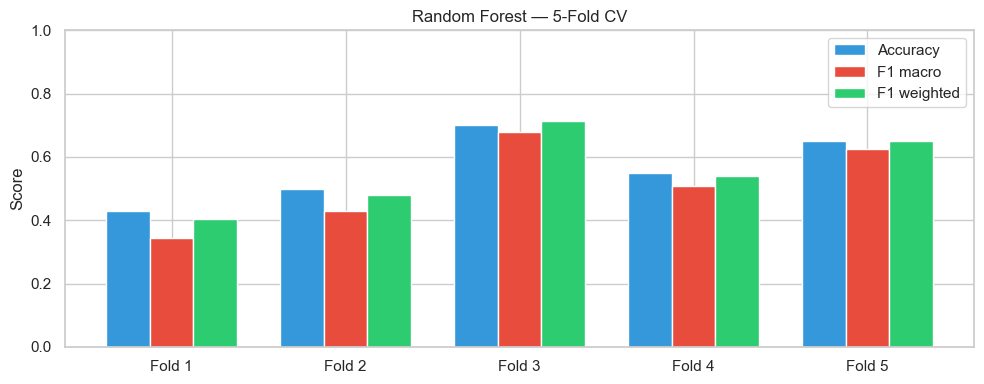

In [23]:
cv = rf_result.cv_results
holdout = rf_result.holdout_metrics

comparison = pd.DataFrame({
    "CV (mean \u00b1 std)": {
        "Accuracy": f"{cv['accuracy_mean']:.3f} \u00b1 {cv['accuracy_std']:.3f}",
        "F1 macro": f"{cv['f1_macro_mean']:.3f} \u00b1 {cv['f1_macro_std']:.3f}",
        "F1 weighted": f"{cv['f1_weighted_mean']:.3f} \u00b1 {cv['f1_weighted_std']:.3f}",
    },
    "Hold-out": {
        "Accuracy": f"{holdout['accuracy']:.3f}",
        "F1 macro": f"{holdout['f1_macro']:.3f}",
        "F1 weighted": f"{holdout['f1_weighted']:.3f}",
    },
})
print("=== Random Forest: CV vs Hold-out ===")
display(comparison)

plot_cv_folds(cv, title=f"Random Forest \u2014 {config.CV_FOLDS}-Fold CV")
plt.show()

=== Hold-out Classification Report ===
              precision    recall  f1-score   support

      Losers       0.33      0.22      0.27         9
      Steady       0.53      0.59      0.56        17
     Winners       0.33      0.38      0.35         8

    accuracy                           0.44        34
   macro avg       0.40      0.40      0.39        34
weighted avg       0.43      0.44      0.43        34



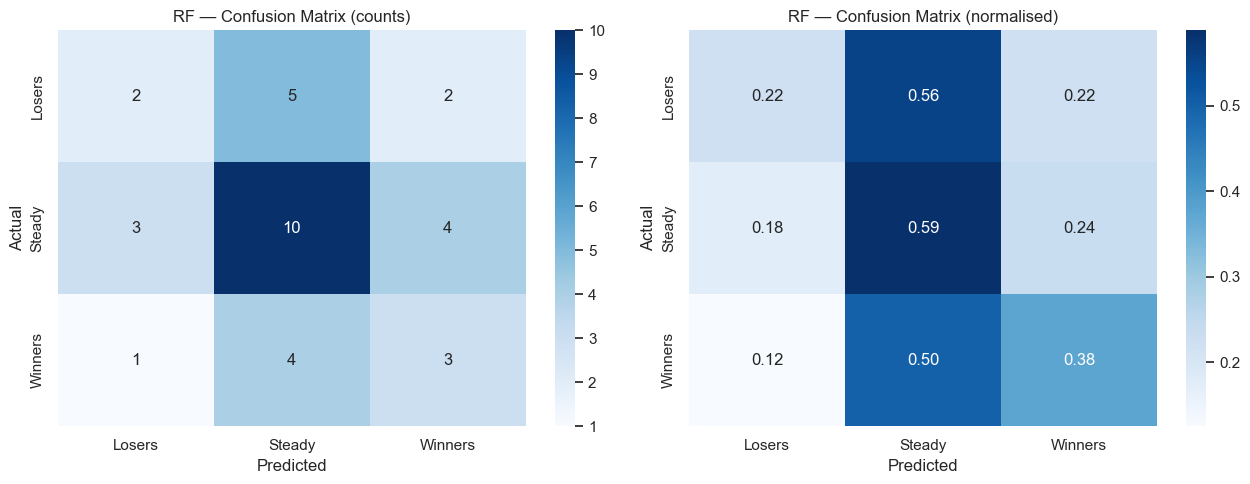

In [24]:
print("=== Hold-out Classification Report ===")
print(holdout["report_str"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_confusion_matrix(
    holdout, rf_result.class_names,
    title="RF \u2014 Confusion Matrix (counts)",
    ax=axes[0],
)
plot_confusion_matrix(
    holdout, rf_result.class_names,
    title="RF \u2014 Confusion Matrix (normalised)",
    normalize=True,
    ax=axes[1],
)
plt.tight_layout()
plt.show()

## SHAP-Analyse

TreeExplainer on the Random Forest model. Per-class mean |SHAP| values reveal which features drive each classification group.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Mean |SHAP| per class:


,Losers,Steady,Winners
feature,,,
mom_1m,0.0040,0.0083,0.0085
mom_3m,0.0088,0.0108,0.0056
mom_6m,0.0037,0.0067,0.0052
rsi_14,0.0041,0.0056,0.0043
roc_10,0.0044,0.0148,0.0121
sma_ratio_50_200,0.0050,0.0131,0.0114
macd_diff_norm,0.0022,0.0027,0.0018
adx_14,0.0067,0.0056,0.0029
hvol_20d,0.0100,0.0179,0.0263


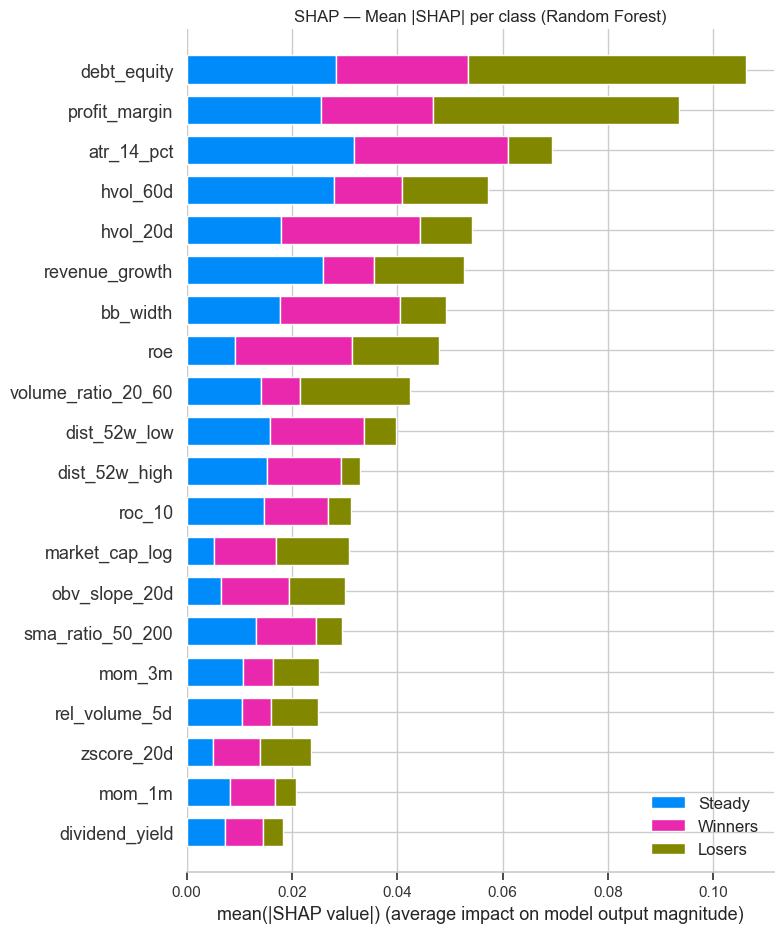

In [25]:
shap_data = shap_explain(rf_result)

print("Mean |SHAP| per class:")
display(shap_data["mean_abs_shap"].round(4))

import shap

sv = shap_data["shap_values"]
sv_list = [sv[:, :, i] for i in range(sv.shape[2])] if sv.ndim == 3 else sv

plt.figure(figsize=(10, 6))
shap.summary_plot(
    sv_list,
    shap_data["X_display"].values,
    feature_names=shap_data["feature_names"],
    class_names=shap_data["class_names"],
    plot_type="bar",
    show=False,
)
plt.title("SHAP \u2014 Mean |SHAP| per class (Random Forest)")
plt.tight_layout()
plt.show()

## XGBoost — Vergleichsmodell

Same pipeline with Gradient Boosting (XGBoost) for comparison.

In [26]:
%%time

xgb_result = train_classifier(
    X, y,
    random_state=config.RANDOM_SEED,
    model_type="xgb",
    tune=True,
)

print(f"\nBest XGBoost hyperparameters:")
for k, v in xgb_result.best_params.items():
    print(f"  {k}: {v}")

print(f"\n=== XGBoost Hold-out ===")
print(xgb_result.holdout_metrics["report_str"])


Best XGBoost hyperparameters:
  colsample_bytree: 0.8
  learning_rate: 0.01
  max_depth: 7
  n_estimators: 300
  subsample: 1.0

=== XGBoost Hold-out ===
              precision    recall  f1-score   support

      Losers       0.00      0.00      0.00         9
      Steady       0.57      0.71      0.63        17
     Winners       0.30      0.38      0.33         8

    accuracy                           0.44        34
   macro avg       0.29      0.36      0.32        34
weighted avg       0.36      0.44      0.39        34

CPU times: user 4.59 s, sys: 9.13 s, total: 13.7 s
Wall time: 22.2 s


,CV Accuracy,CV F1 macro,Holdout Accuracy,Holdout F1 macro,Holdout F1 weighted
Model,,,,,
Random Forest,0.566 ± 0.098,0.517 ± 0.123,0.441,0.392,0.431
XGBoost,0.634 ± 0.045,0.555 ± 0.064,0.441,0.322,0.394


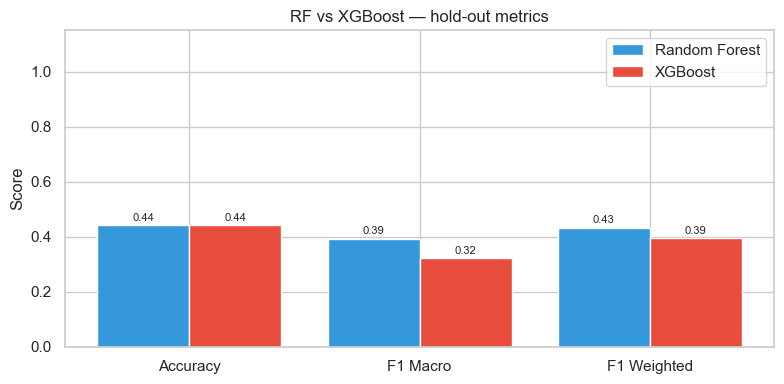

In [27]:
models = {"Random Forest": rf_result, "XGBoost": xgb_result}

summary_rows = []
for name, res in models.items():
    cv = res.cv_results
    ho = res.holdout_metrics
    summary_rows.append({
        "Model": name,
        "CV Accuracy": f"{cv['accuracy_mean']:.3f} \u00b1 {cv['accuracy_std']:.3f}",
        "CV F1 macro": f"{cv['f1_macro_mean']:.3f} \u00b1 {cv['f1_macro_std']:.3f}",
        "Holdout Accuracy": f"{ho['accuracy']:.3f}",
        "Holdout F1 macro": f"{ho['f1_macro']:.3f}",
        "Holdout F1 weighted": f"{ho['f1_weighted']:.3f}",
    })
display(pd.DataFrame(summary_rows).set_index("Model"))

plot_model_comparison(models, title="RF vs XGBoost \u2014 hold-out metrics")
plt.show()

## Finales Modell — Refit & Speichern

Select the better model by hold-out F1-macro, then **retrain on all Q1 2024 labelled data** (no hold-out) to maximise the training base for the 2025 forward test.

In [28]:
rf_f1 = rf_result.holdout_metrics["f1_macro"]
xgb_f1 = xgb_result.holdout_metrics["f1_macro"]

if rf_f1 >= xgb_f1:
    best_name, best_result = "Random Forest", rf_result
else:
    best_name, best_result = "XGBoost", xgb_result

print(f"Selected model: {best_name}  (hold-out F1-macro = {best_result.holdout_metrics['f1_macro']:.3f})")

final_result = refit_on_full_data(X, y, best_result, random_state=config.RANDOM_SEED)
print(f"Refit on {len(final_result.X_train)} samples (full Q1 2024 labelled data)")
print(f"Features: {len(final_result.feature_names)}")

model_path = config.DATA_DIR / "models" / "final_classifier.joblib"
save_model(final_result, model_path)
print(f"\n\u2705 Final model saved to {model_path}")

Selected model: Random Forest  (hold-out F1-macro = 0.392)
Refit on 135 samples (full Q1 2024 labelled data)
Features: 28

✅ Final model saved to /Users/stephangath/cursorAi/Stock Analysis AI/data/models/final_classifier.joblib


## Zusammenfassung

| Schritt | Ergebnis |
|---|---|
| Stratified Split | 75 % Train / 25 % Hold-out |
| GridSearchCV | 5-Fold, optimiert auf F1-macro |
| Modellvergleich | RF vs XGBoost |
| SHAP | Gruppenspezifische Feature-Beiträge |
| Finales Modell | Refit auf alle Q1-2024-Daten → `data/models/final_classifier.joblib` |

**Nächster Schritt:** Notebook 06 — Out-of-sample Forward-Test (2025) mit dem gespeicherten Modell.